In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split

from datetime import datetime as dt

%matplotlib inline

path = "/Users/emiller/Documents/sf_tech/sf_datasets/"

amzn_cat_csv = pd.read_csv(path + "amazon_categories.csv")
amzn_prod_csv = pd.read_csv(path + "amazon_products.csv")


pd.set_option('display.max_columns', None)

print('complete')

complete


In [2]:
amzn_merged_csv = pd.merge(amzn_cat_csv, amzn_prod_csv, left_on='id', right_on='category_id', how='inner')

In [3]:
# drop columns that are not needed, and make column names lowercase

drop_cols = ['id', 'imgUrl', 'productURL']

amzn_merged_df = amzn_merged_csv.drop(drop_cols, axis='columns')

amzn_merged_df = (
    amzn_merged_df.rename(columns=str.lower)
    .rename(columns={'listprice': 'list_price', 'isbestseller': 'best_seller', 'boughtinlastmonth': 'bought_in_last_month'})
    )


## EDA

In [4]:
# amzn_merged_df['stars_bin'] = amzn_merged_df['stars'].round(0)
# amzn_merged_df.head(20)

In [5]:
""" clean columns """
# price and list price to coalesce each other
amzn_merged_df['list_price'] = np.where(amzn_merged_df['list_price'] == 0, amzn_merged_df['price'], amzn_merged_df['list_price'])


""" CREATE NEW COLUMNS """
# create discount column from price and list price
amzn_merged_df['discount_rate'] = (
    (amzn_merged_df['list_price'] - amzn_merged_df['price']) / amzn_merged_df['list_price']
)


# 'category' dummy variables? top 10 unique values from amazon_cat_csv
top_cats = amzn_merged_df.category_name.value_counts().nlargest(10).index.to_list()

amzn_merged_df['category_group'] = (amzn_merged_df['category_name']
                                    .where(amzn_merged_df['category_name'].isin(top_cats), 'other'))

amzn_merged_df['category_group'] = (
    amzn_merged_df['category_group']
    .str.replace(' ', '_')
    .str.replace("'", '')
    .str.replace('&', 'and')
    .str.lower()
)

# create discrete columns from bought_in_last_month, discount_rate, and stars fields
amzn_merged_df['bought_last_month_flag'] = amzn_merged_df['bought_in_last_month'] > 0
amzn_merged_df['discount_flag'] = amzn_merged_df['discount_rate'] > 0
amzn_merged_df['stars_bin'] = amzn_merged_df['stars'].round(0)





In [6]:
# amzn_merged_df.category_group.value_counts()
# top_cats
# amzn_merged_df.category_name.value_counts().nlargest(10).index.to_list()

In [7]:
""" get dummies - turn categorical values into columns """
amzn_dummies_df = pd.get_dummies(amzn_merged_df.category_group)
amzn_df = amzn_merged_df.join(amzn_dummies_df)
amzn_df.head()

# remove columns: ['asin', 'title', 'category_id', 'category_name'] + 1 of the 'category' values
drops = ['asin', 'title', 'category_id', 'category_name']
amzn_df.drop(drops, axis='columns', inplace=True)

amzn_df.head()

,stars,reviews,price,list_price,best_seller,bought_in_last_month,discount_rate,category_group,bought_last_month_flag,discount_flag,stars_bin,boys_clothing,girls_clothing,girls_jewelry,mens_accessories,mens_clothing,mens_shoes,other,toys_and_games,womens_clothing,womens_handbags,womens_jewelry
0,4.7,510,9.99,9.99,False,50,0.0,other,True,False,5.0,False,False,False,False,False,False,True,False,False,False,False
1,4.6,584,8.99,8.99,False,0,0.0,other,False,False,5.0,False,False,False,False,False,False,True,False,False,False,False
2,4.5,245,12.79,12.79,False,50,0.0,other,True,False,4.0,False,False,False,False,False,False,True,False,False,False,False
3,5.0,1,16.99,16.99,False,0,0.0,other,False,False,5.0,False,False,False,False,False,False,True,False,False,False,False
4,4.4,10,15.99,15.99,False,50,0.0,other,True,False,4.0,False,False,False,False,False,False,True,False,False,False,False


In [8]:
"""
calculations
"""
# ############## For Products
# descriptive stats for products
ntiles = [0.2, 0.4, 0.6, 0.8]
amzn_df[['price', 'list_price', 'discount_rate', 'reviews', 'stars']].describe(percentiles=ntiles)

# percentage best sellers
len(amzn_df[amzn_df['best_seller'] == True]) / len(amzn_df)

# percentage of purchases with discounts
len(amzn_df[amzn_df['discount_rate'] > 0]) / len(amzn_df)

# amzn_df.head()




0.24198699185395878

In [9]:
""" Descriptive stats for categories """

# descriptive stats
desc_stats = amzn_df.groupby('category_group').describe()

# percentage best sellers
best_seller_pct = amzn_df.groupby('category_group')['best_seller'].mean()

# percentage w/ reviews
review_pct = (amzn_df['reviews'] > 0).groupby(amzn_df['category_group']).mean()

# percentage of purchases with discounts
discounts_pct = (amzn_df['discount_rate'] != 0).groupby(amzn_df['category_group']).mean()




### SCATTERPLOTS

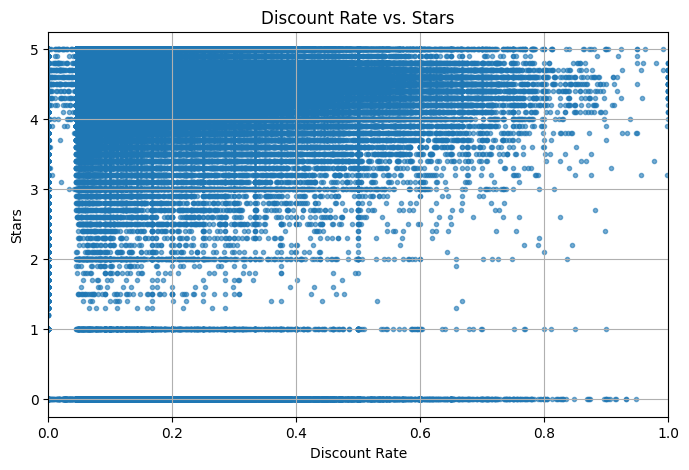

In [10]:
""" DISCOUNT RATE VS STARS """

plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['discount_rate'], amzn_df['stars'], marker='.', alpha=0.6)
plt.xlim(0, 1.0)     # Set x-axis range
# plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Discount Rate')
plt.ylabel('Stars')
plt.title('Discount Rate vs. Stars')
plt.grid(True)
plt.show()

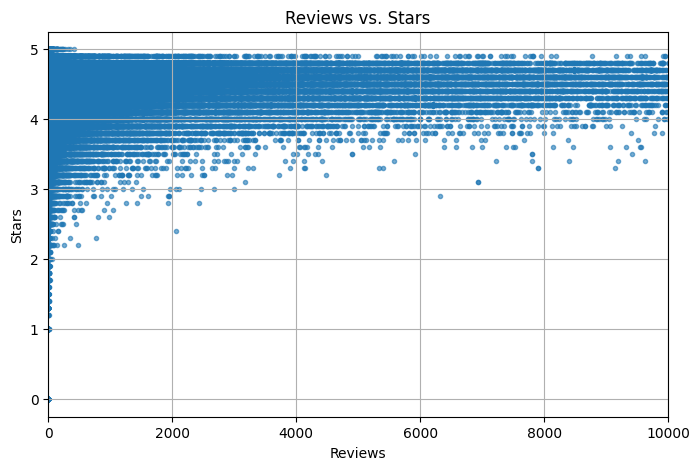

In [11]:
""" REVIEWS VS STARS """

plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['reviews'], amzn_df['stars'], marker='.', alpha=0.6)
plt.xlim(0, 10000)     # Set x-axis range
# plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Reviews')
plt.ylabel('Stars')
plt.title('Reviews vs. Stars')
plt.grid(True)
plt.show()

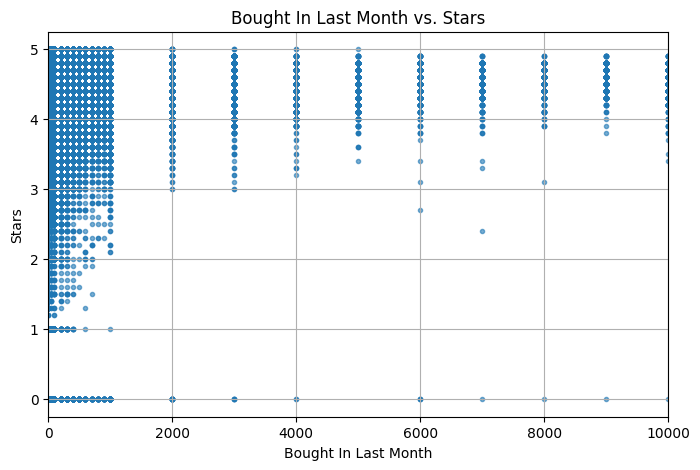

In [12]:
""" BOUGHT_IN_LAST_MONTH VS STARS """

plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['bought_in_last_month'], amzn_df['stars'], marker='.', alpha=0.6)
plt.xlim(0, 10000)     # Set x-axis range - values go to 100000, frequency fades past 10000
# plt.ylim(0, 15000)       # Set y-axis range
plt.xlabel('Bought In Last Month')
plt.ylabel('Stars')
plt.title('Bought In Last Month vs. Stars')
plt.grid(True)
plt.show()

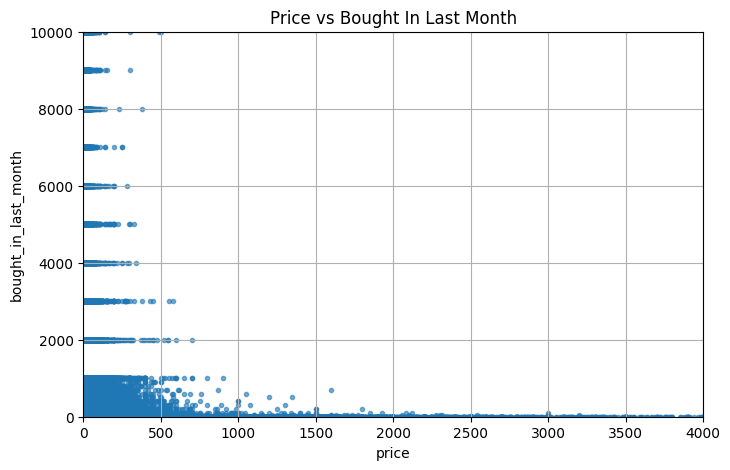

In [13]:
""" PRICE VS BOUGHT_IN_LAST_MONTH """

plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['price'], amzn_df['bought_in_last_month'], marker='.', alpha=0.6)
plt.xlim(0, 4000)     # Set x-axis range
plt.ylim(0, 10000)       # Set y-axis range - values go to 100000, frequency fades past 10000
plt.xlabel('price')
plt.ylabel('bought_in_last_month')
plt.title('Price vs Bought In Last Month')
plt.grid(True)
plt.show()

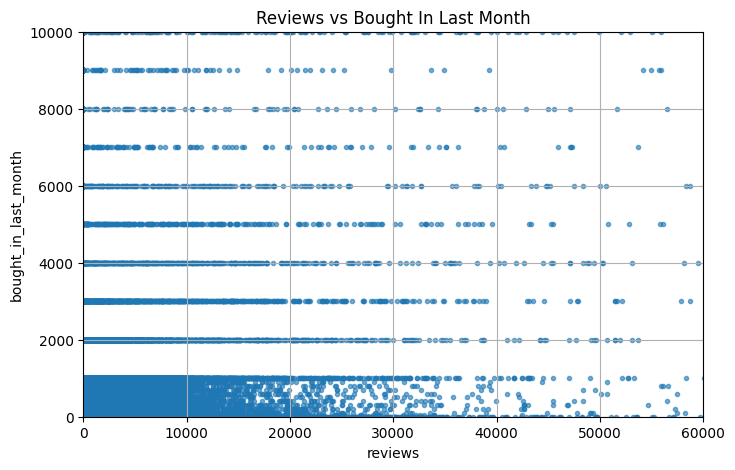

In [14]:
""" REVIEWS VS BOUGHT_IN_LAST_MONTH """

plt.figure(figsize=(8, 5))
plt.scatter(amzn_df['reviews'], amzn_df['bought_in_last_month'], marker='.', alpha=0.6)
plt.xlim(0, 60000)     # Set x-axis range
plt.ylim(0, 10000)       # Set y-axis range - values go to 100000, frequency fades past 10000
plt.xlabel('reviews')
plt.ylabel('bought_in_last_month')
plt.title('Reviews vs Bought In Last Month')
plt.grid(True)
plt.show()

### BAR CHARTS

In [15]:
# amzn_df['bought_last_month_flag'].value_counts()
# .sum()

# amzn_df[amzn_df['best_seller'] == True].bought_last_month_flag.value_counts()


# bought_last_month_flag
# False    917620
# True     508717
# 1426337

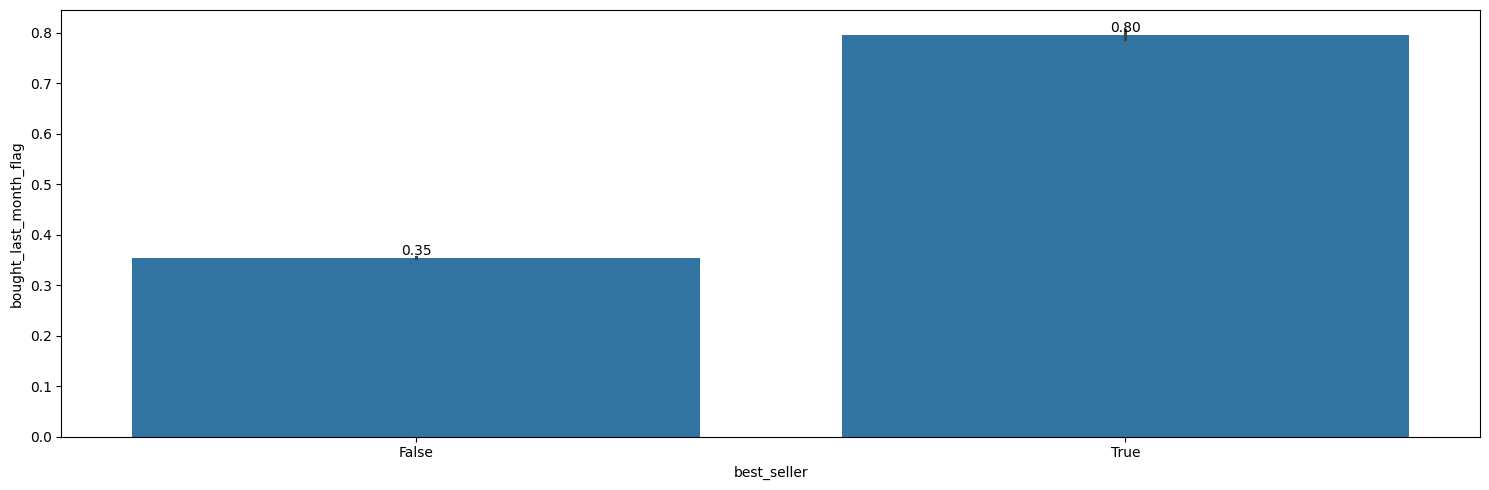

In [16]:
""" BEST_SELLER VS BOUGHT_IN_LAST_MONTH (BINARY %)"""

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="best_seller", y="bought_last_month_flag", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

# plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

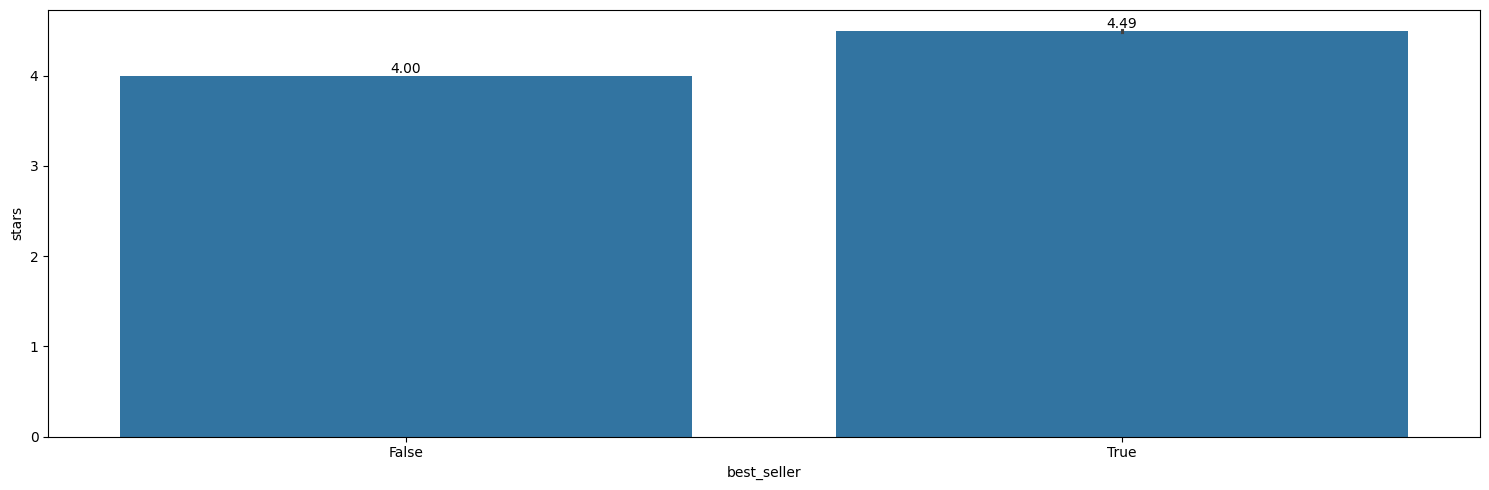

In [17]:
""" BEST_SELLER VS STARS (AVG)"""
plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="best_seller", y="stars", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

# plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

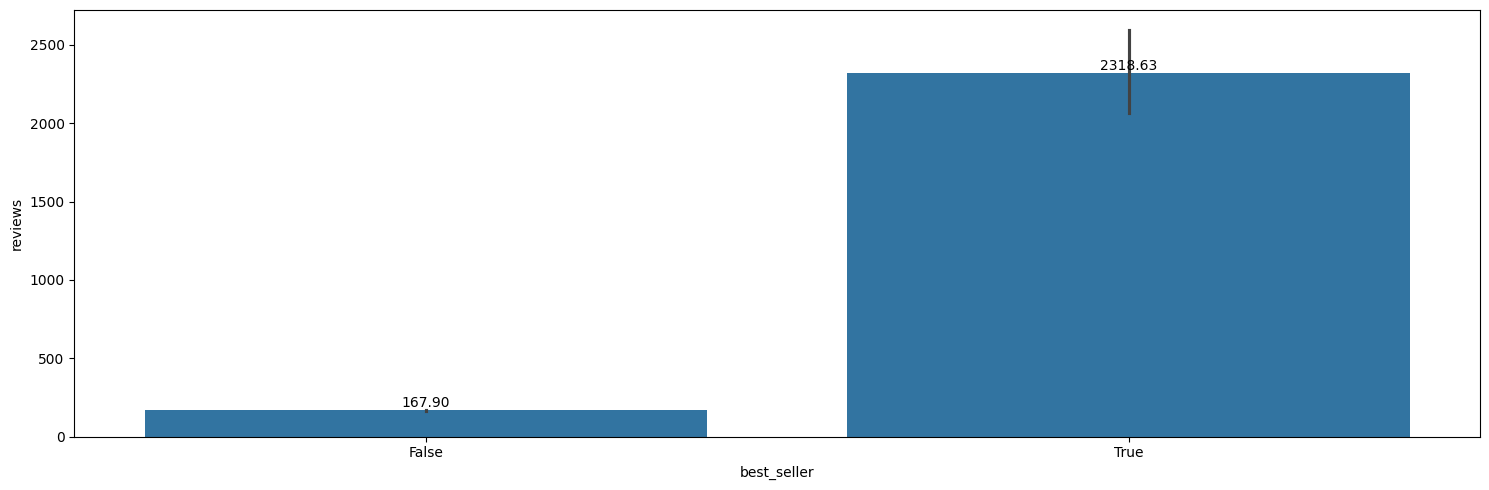

In [18]:
""" BEST_SELLER VS REVIEWS (AVG)"""
plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="best_seller", y="reviews", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

# plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

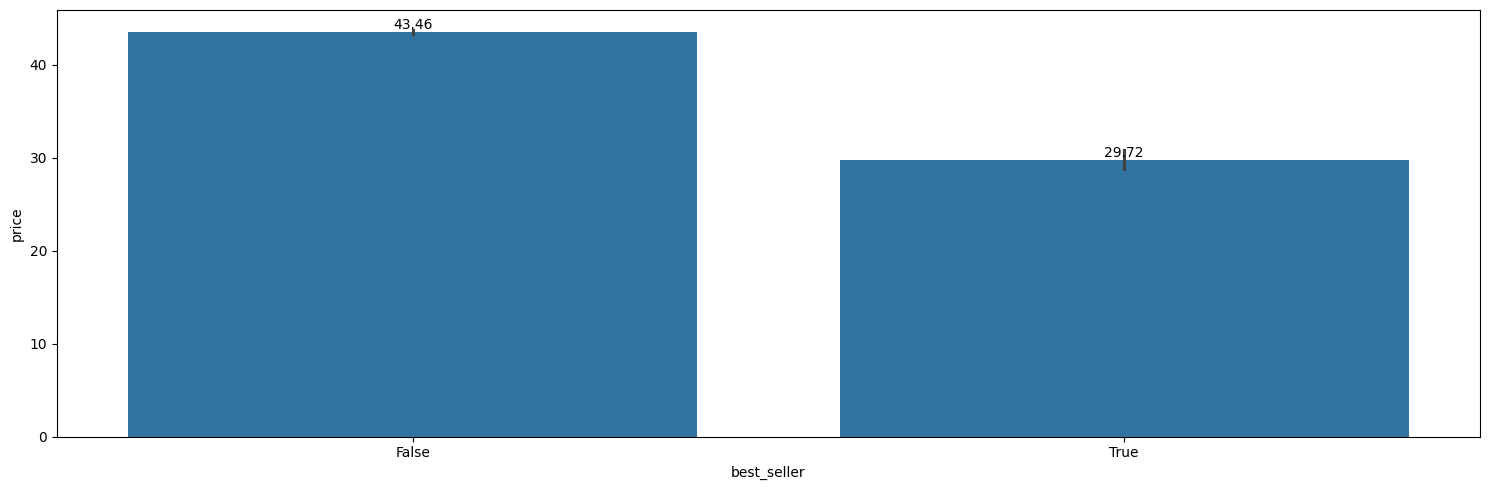

In [19]:
""" BEST_SELLER VS PRICE (AVG)"""

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="best_seller", y="price", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

# plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

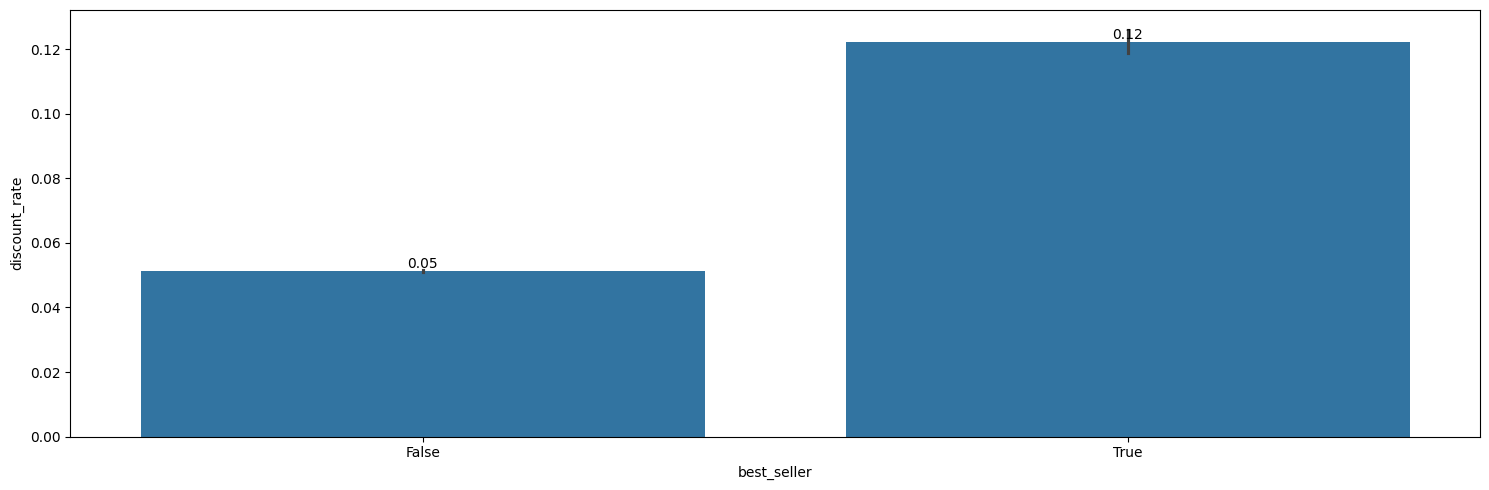

In [20]:
""" BEST_SELLER VS DISCOUNT RATE (AVG)"""

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="best_seller", y="discount_rate", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

# plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

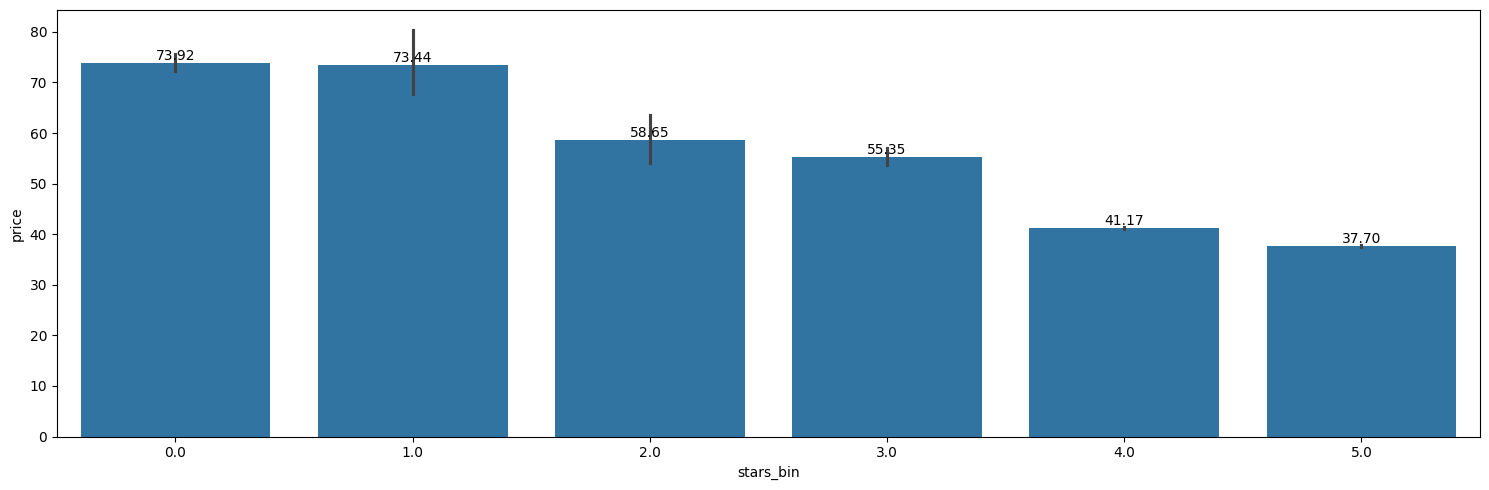

In [21]:
""" STARS (BINS) VS PRICE (AVG)"""

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="stars_bin", y="price", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

# plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

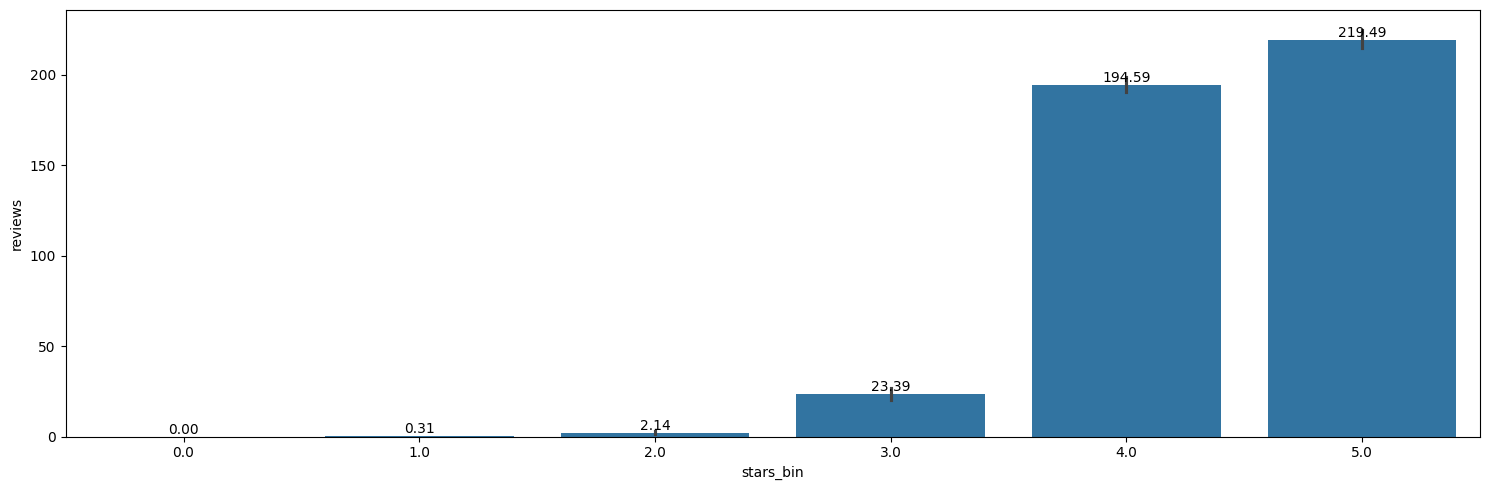

In [22]:
""" STARS (BINS) VS REVIEWS (AVG)"""

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="stars_bin", y="reviews", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

# plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

In [23]:
# amzn_df[amzn_df['stars_bin'] == 1].head(10)

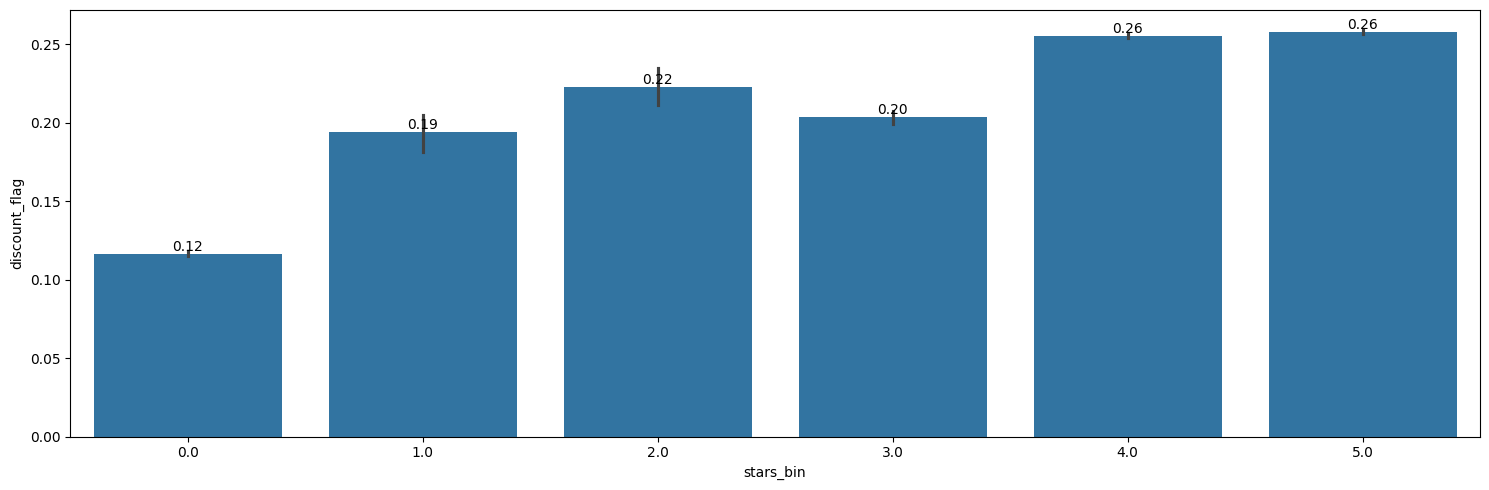

In [24]:
""" STARS (BINS) VS DISCOUNT (BINARY) """

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="stars_bin", y="discount_flag", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

# plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

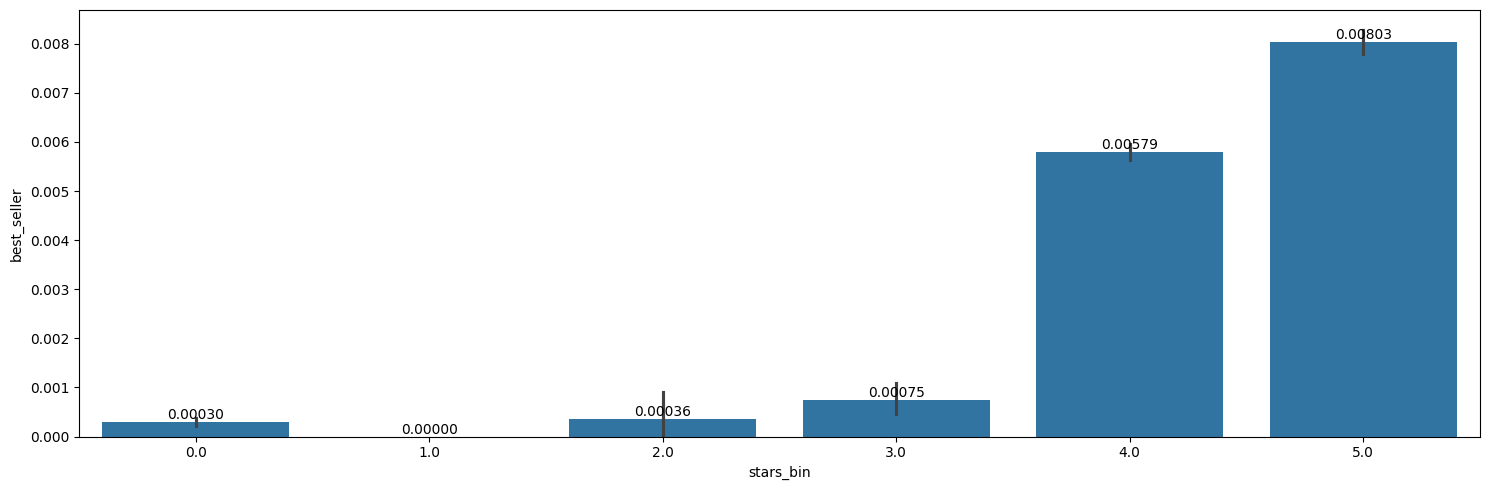

In [25]:
""" STARS (BINS) VS BEST_SELLER (%)"""

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="stars_bin", y="best_seller", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.5f")  # integer labels

# plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

In [26]:
# how, Sway? Zero reviews, zero stars, but bestseller -- 39 instances
# amzn_df[(amzn_df['stars_bin'] == 0) & (amzn_df['best_seller'] == True)]


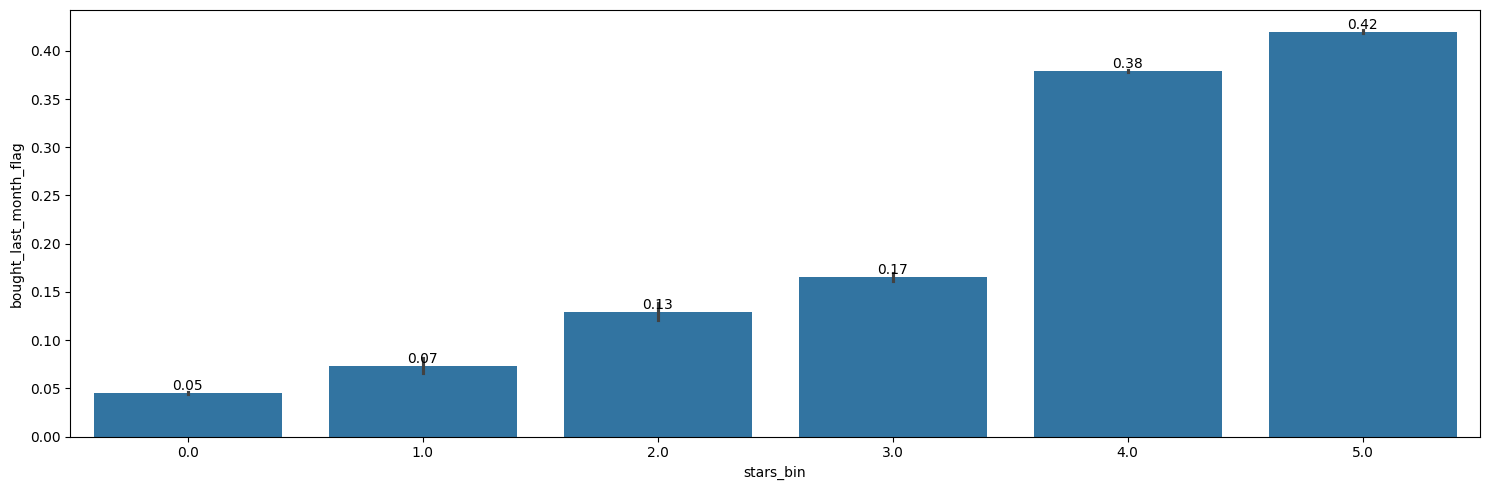

In [27]:
""" STARS (BINS) VS BOUGHT_IN_LAST_MONTH (BINARY %) """

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="stars_bin", y="bought_last_month_flag", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

# plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

In [28]:
# amzn_df['category_group'].value_counts()
amzn_df.head()

,stars,reviews,price,list_price,best_seller,bought_in_last_month,discount_rate,category_group,bought_last_month_flag,discount_flag,stars_bin,boys_clothing,girls_clothing,girls_jewelry,mens_accessories,mens_clothing,mens_shoes,other,toys_and_games,womens_clothing,womens_handbags,womens_jewelry
0,4.7,510,9.99,9.99,False,50,0.0,other,True,False,5.0,False,False,False,False,False,False,True,False,False,False,False
1,4.6,584,8.99,8.99,False,0,0.0,other,False,False,5.0,False,False,False,False,False,False,True,False,False,False,False
2,4.5,245,12.79,12.79,False,50,0.0,other,True,False,4.0,False,False,False,False,False,False,True,False,False,False,False
3,5.0,1,16.99,16.99,False,0,0.0,other,False,False,5.0,False,False,False,False,False,False,True,False,False,False,False
4,4.4,10,15.99,15.99,False,50,0.0,other,True,False,4.0,False,False,False,False,False,False,True,False,False,False,False


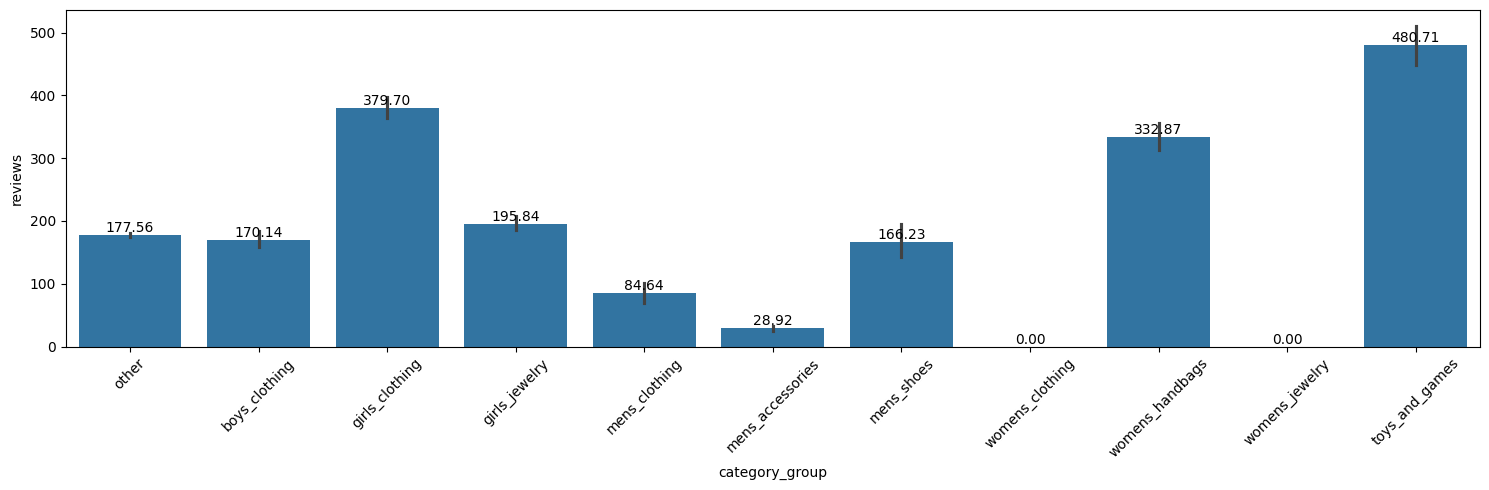

In [29]:
""" CATEGORIES VS REVIEWS (AVG)"""

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="category_group", y="reviews", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

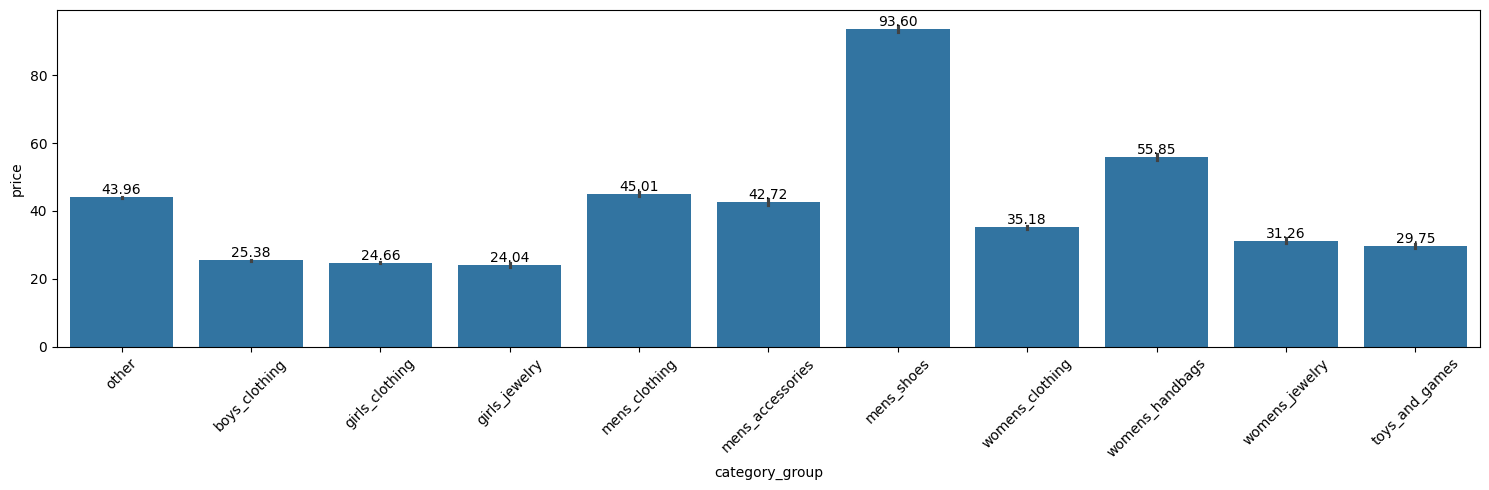

In [30]:
""" CATEGORIES VS PRICE (AVG)"""

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="category_group", y="price", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

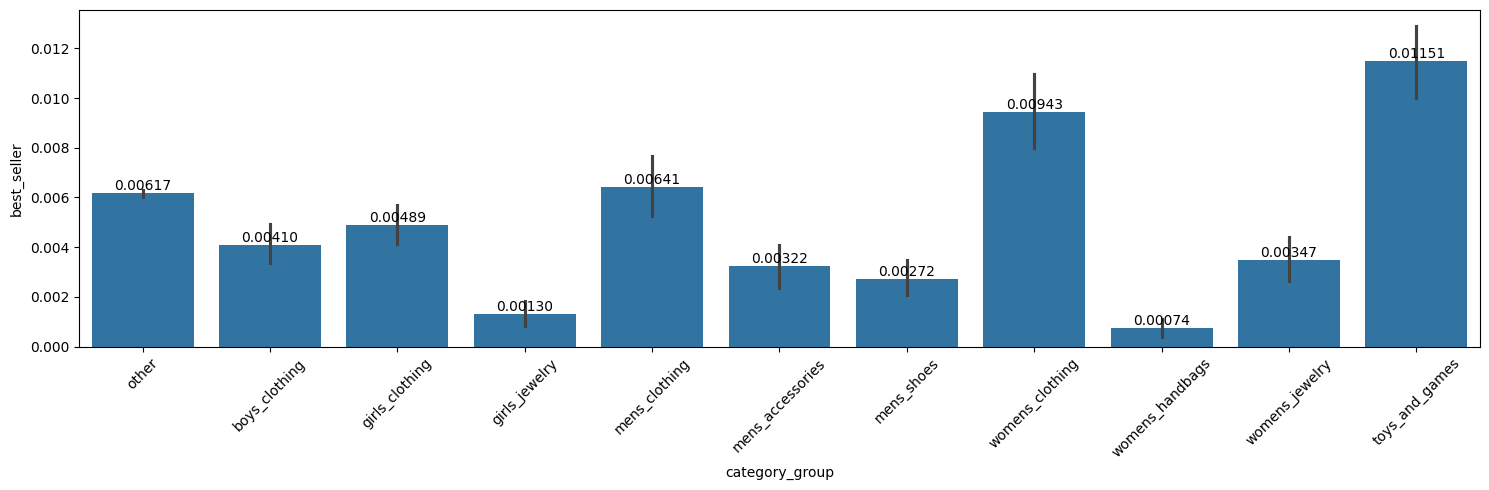

In [31]:
""" CATEGORIES VS BEST_SELLER (%) """

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="category_group", y="best_seller", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.5f")  # integer labels

plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

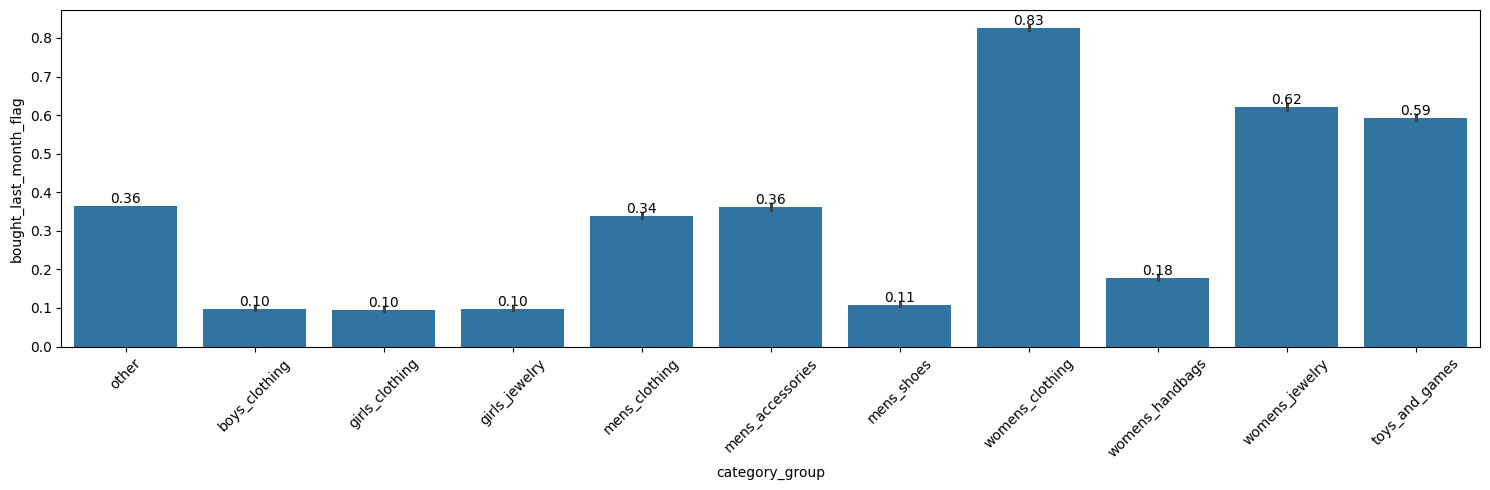

In [32]:
""" CATEGORIES VS BOUGHT_IN_LAST_MONTH (BINARY %) """

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="category_group", y="bought_last_month_flag", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

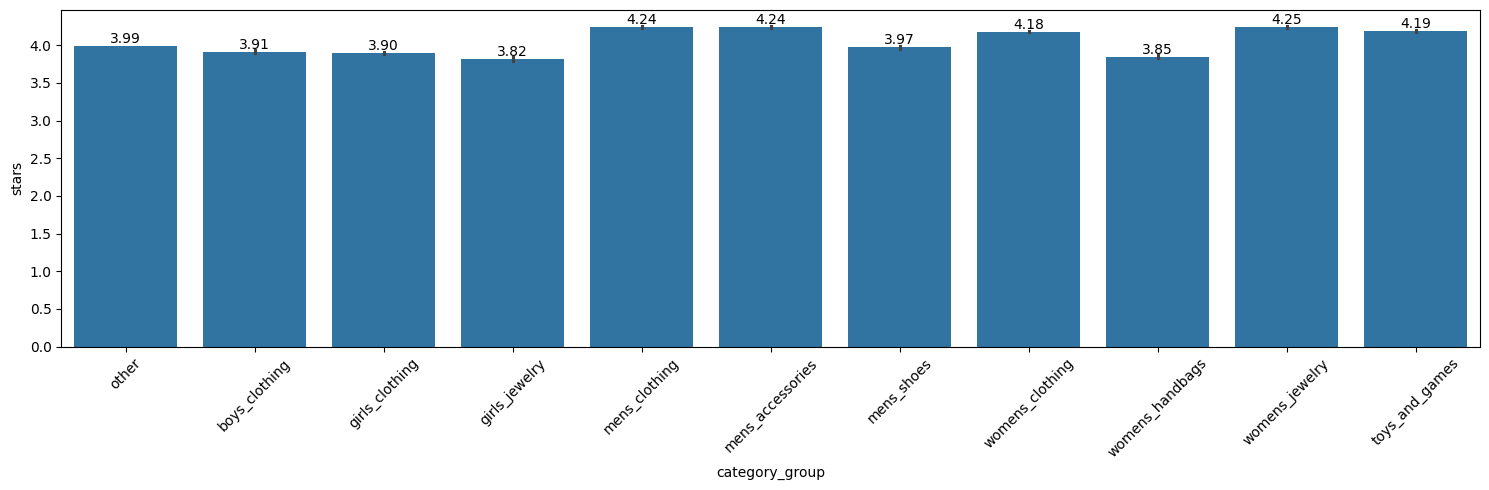

In [33]:
""" CATEGORIES VS STARS (AVG) """

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="category_group", y="stars", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

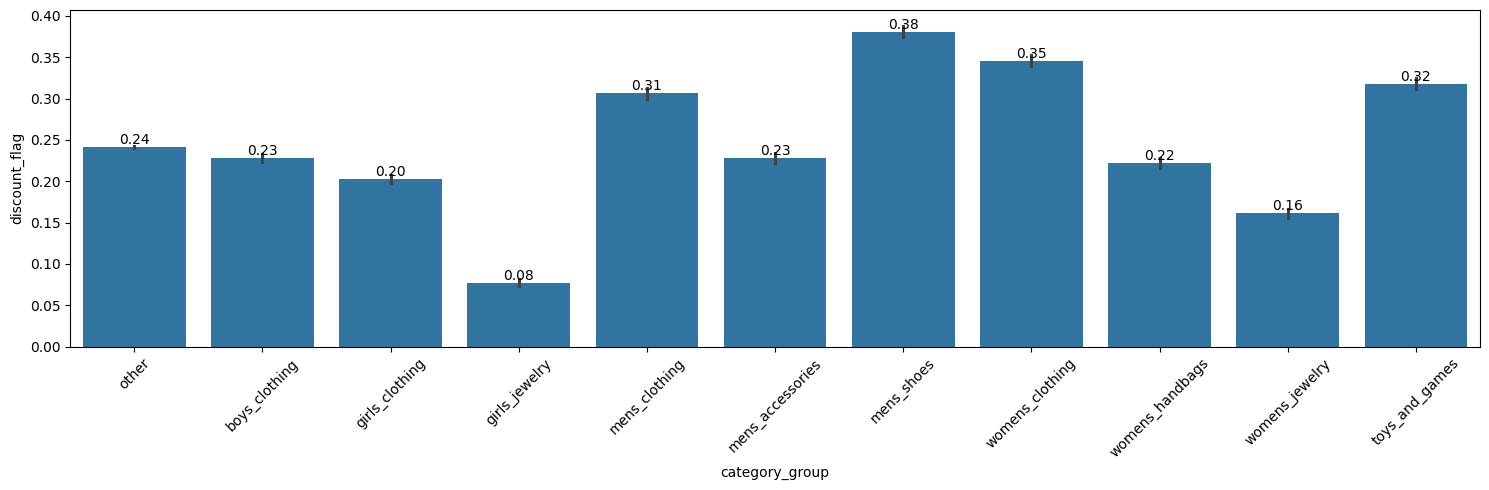

In [34]:
""" CATEGORIES VS DISCOUNT (BINARY) """

plt.figure(figsize=(15, 5))  # width=8, height=5 inches
ax = sns.barplot(x="category_group", y="discount_flag", data=amzn_df)
ax.bar_label(ax.containers[0], fmt="%.2f")  # integer labels

plt.xticks(rotation=45)   # rotate 45 degrees
plt.tight_layout()        # auto-adjust layout to avoid cutoff
plt.show()

#### Scatterplots with Log Transformations

/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


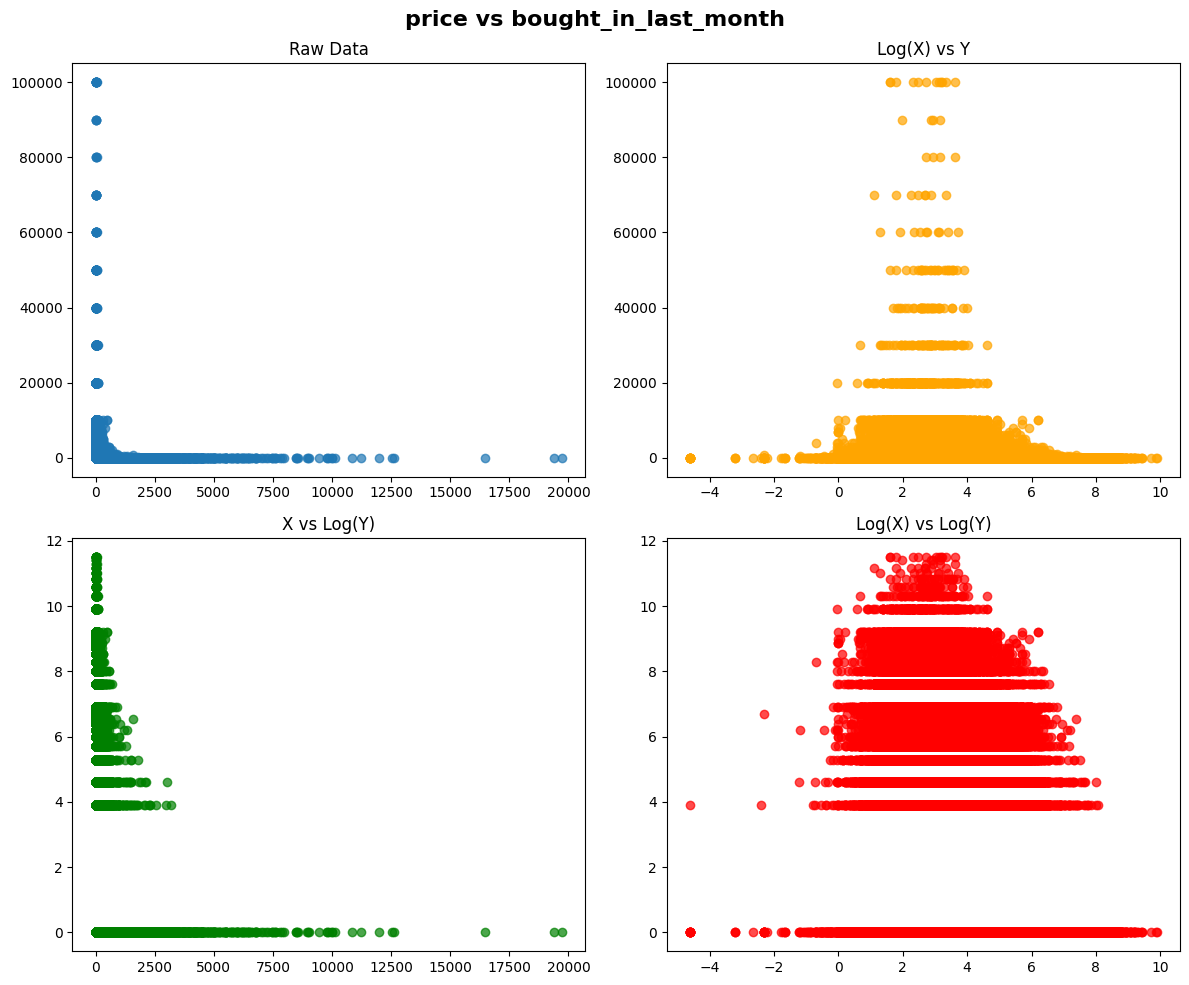

In [35]:

# transformation graphs: X vs Y; Log(X) vs Y; X vs Log(Y); Log(X) vs Log(Y)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example data (replace with your own)
np.random.seed(42)
"""
price vs bought_in_last_month
"""

# Set up 2x2 plot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Overall title for the entire grid
fig.suptitle("price vs bought_in_last_month", fontsize=16, weight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for the suptitle

# Raw data
axes[0,0].scatter(amzn_df["price"], amzn_df["bought_in_last_month"], alpha=0.7)
axes[0,0].set_title("Raw Data")

# Log on X
axes[0,1].scatter(np.log(amzn_df["price"]), amzn_df["bought_in_last_month"], alpha=0.7, color="orange")
axes[0,1].set_title("Log(X) vs Y")

# Log on Y
axes[1,0].scatter(amzn_df["price"], np.log(amzn_df["bought_in_last_month"].clip(lower=1)), alpha=0.7, color="green")
axes[1,0].set_title("X vs Log(Y)")

# Log-Log
axes[1,1].scatter(np.log(amzn_df["price"]), np.log(amzn_df["bought_in_last_month"].clip(lower=1)), alpha=0.7, color="red")
axes[1,1].set_title("Log(X) vs Log(Y)")

plt.tight_layout()
plt.show()

/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


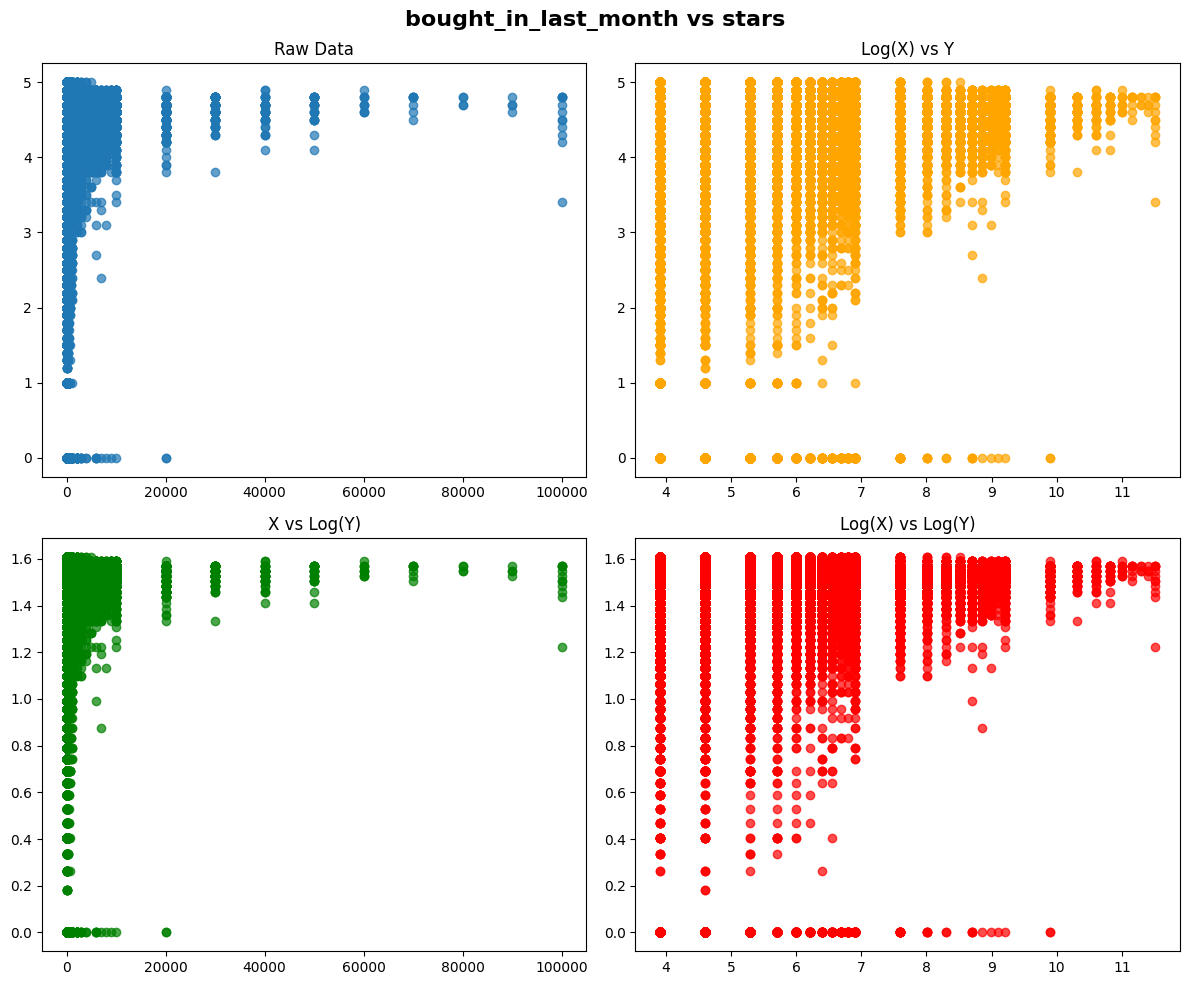

In [36]:
"""
bought_in_last_month vs stars 
"""

# Set up 2x2 plot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Overall title for the entire grid
fig.suptitle("bought_in_last_month vs stars", fontsize=16, weight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for the suptitle

# Raw data
axes[0,0].scatter(amzn_df["bought_in_last_month"], amzn_df["stars"], alpha=0.7)
axes[0,0].set_title("Raw Data")

# Log on X
axes[0,1].scatter(np.log(amzn_df["bought_in_last_month"]), amzn_df["stars"], alpha=0.7, color="orange")
axes[0,1].set_title("Log(X) vs Y")

# Log on Y
axes[1,0].scatter(amzn_df["bought_in_last_month"], np.log(amzn_df["stars"].clip(lower=1)), alpha=0.7, color="green")
axes[1,0].set_title("X vs Log(Y)")

# Log-Log
axes[1,1].scatter(np.log(amzn_df["bought_in_last_month"]), np.log(amzn_df["stars"].clip(lower=1)), alpha=0.7, color="red")
axes[1,1].set_title("Log(X) vs Log(Y)")

plt.tight_layout()
plt.show()

/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/emiller/Documents/sf_tech/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


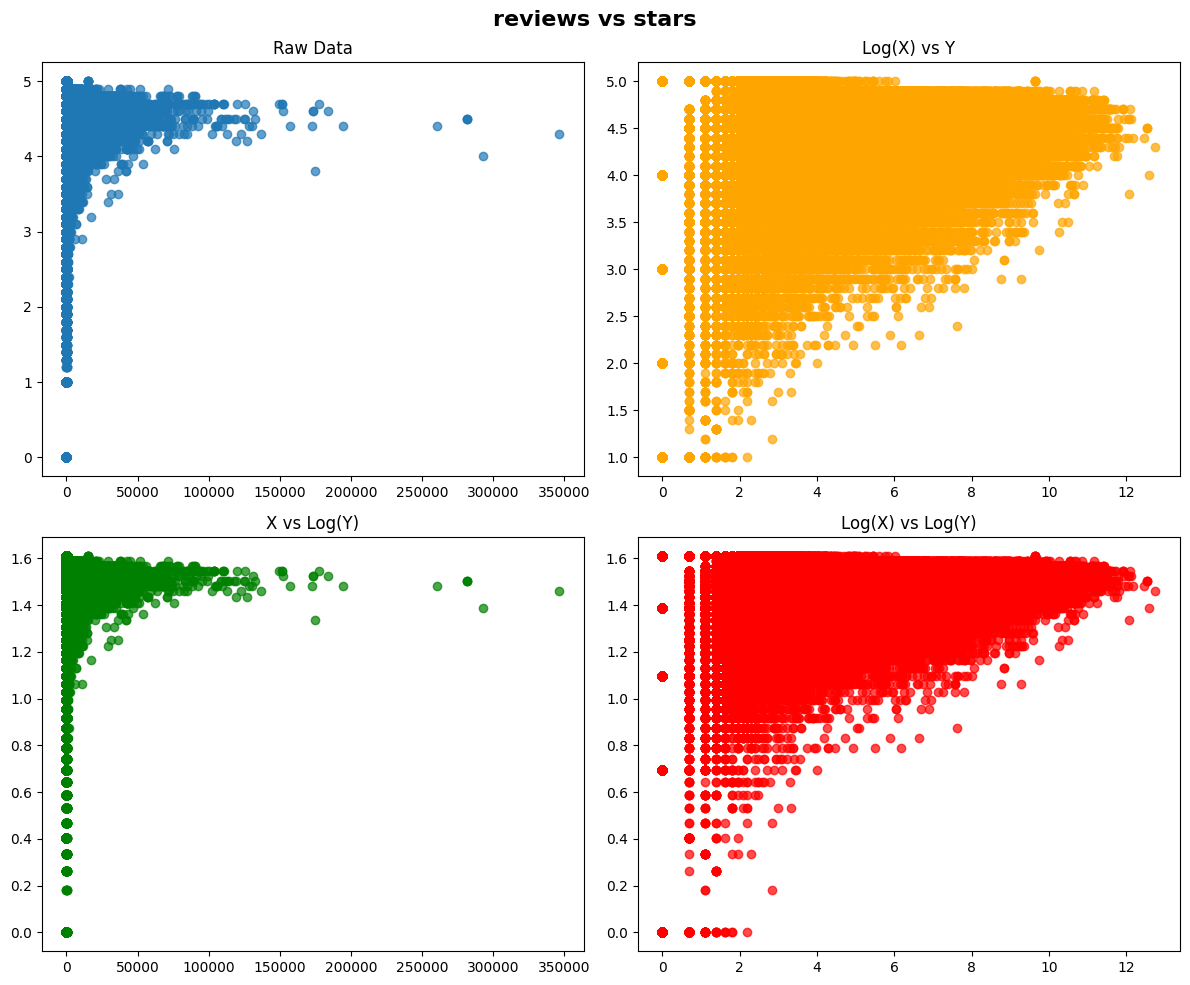

In [37]:
"""
reviews vs stars 
"""

# Set up 2x2 plot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Overall title for the entire grid
fig.suptitle("reviews vs stars", fontsize=16, weight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for the suptitle

# Raw data
axes[0,0].scatter(amzn_df["reviews"], amzn_df["stars"], alpha=0.7)
axes[0,0].set_title("Raw Data")

# Log on X
axes[0,1].scatter(np.log(amzn_df["reviews"]), amzn_df["stars"], alpha=0.7, color="orange")
axes[0,1].set_title("Log(X) vs Y")

# Log on Y
axes[1,0].scatter(amzn_df["reviews"], np.log(amzn_df["stars"].clip(lower=1)), alpha=0.7, color="green")
axes[1,0].set_title("X vs Log(Y)")

# Log-Log
axes[1,1].scatter(np.log(amzn_df["reviews"]), np.log(amzn_df["stars"].clip(lower=1)), alpha=0.7, color="red")
axes[1,1].set_title("Log(X) vs Log(Y)")

plt.tight_layout()
plt.show()

In [38]:
top_cats

["Girls' Clothing",
 "Boys' Clothing",
 'Toys & Games',
 "Men's Shoes",
 "Women's Handbags",
 "Girls' Jewelry",
 "Men's Clothing",
 "Men's Accessories",
 "Women's Clothing",
 "Women's Jewelry"]

### Confusion Matrices

In [133]:
amzn = amzn_df.drop(['category_group'], axis='columns')
amzn.head()

,stars,reviews,price,list_price,best_seller,bought_in_last_month,discount_rate,bought_last_month_flag,discount_flag,stars_bin,boys_clothing,girls_clothing,girls_jewelry,mens_accessories,mens_clothing,mens_shoes,other,toys_and_games,womens_clothing,womens_handbags,womens_jewelry
0,4.7,510,9.99,9.99,False,50,0.0,True,False,5.0,False,False,False,False,False,False,True,False,False,False,False
1,4.6,584,8.99,8.99,False,0,0.0,False,False,5.0,False,False,False,False,False,False,True,False,False,False,False
2,4.5,245,12.79,12.79,False,50,0.0,True,False,4.0,False,False,False,False,False,False,True,False,False,False,False
3,5.0,1,16.99,16.99,False,0,0.0,False,False,5.0,False,False,False,False,False,False,True,False,False,False,False
4,4.4,10,15.99,15.99,False,50,0.0,True,False,4.0,False,False,False,False,False,False,True,False,False,False,False


In [ ]:
# stars: ['reviews', 'best_seller', 'bought_last_month_flag']

heatmap_stars = amzn_df['stars', 'reviews', 'best_seller', 'bought_last_month_flag']

# Set seed for reproducibility
np.random.seed(0)

# Correlation matrix
correlation = amzn.corr()

# Plot heatmap
plt.figure(figsize=(16,12))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap - stars_target")
plt.tight_layout()
plt.show()

In [ ]:
heat_drops = ['price', 'list_price', 'discount_rate', 'category_group', 'discount_flag', 'stars_bin', 'other']
heatmap_best_seller = amzn_df.drop([heat_drops], axis='columns')

# Set seed for reproducibility
np.random.seed(0)

# Correlation matrix
correlation = heatmap_best_seller.corr()

# Plot heatmap
plt.figure(figsize=(16,12))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap - best_seller_target")
plt.tight_layout()
plt.show()



In [ ]:
# best_seller: ['stars', 'reviews', 'price', 'bought_last_month', 'boys_clothing'
# , 'girls_clothing', 'girls_jewelry', 'mens_accessories', 'mens_clothing'
# , 'mens_shoes', 'toys_and_games', 'womens_clothing', 'womens_handbags', 'womens_jewelry']